<a href="https://colab.research.google.com/github/paurnavi25/OIBSIP-/blob/main/DataScience_Task3_CarPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [7]:
df = pd.read_csv("car data.csv")
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [8]:
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [9]:
# Missing values
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [10]:
df=df.dropna()

In [11]:
df.duplicated().sum()

np.int64(763)

In [12]:
df = df.drop_duplicates()

In [13]:
df['fuel'].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [14]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [15]:
current_year = 2026
df['Car_Age'] = current_year - df['year']

In [16]:
df['Brand'] = df['name'].str.split().str[0]
df[['name','Brand']].head()

,name,Brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


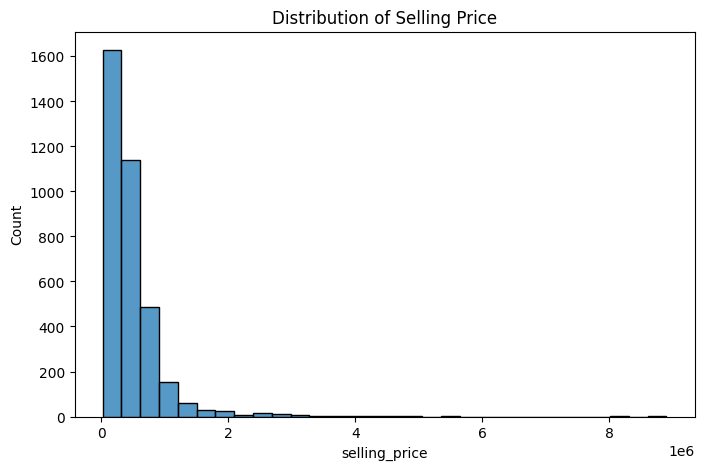

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['selling_price'], bins=30)

plt.title("Distribution of Selling Price")

plt.show()

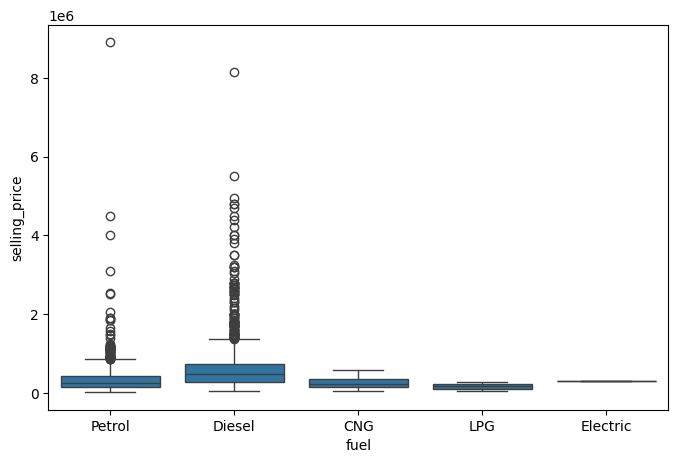

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='fuel',
    y='selling_price',
    data=df
)

plt.show()

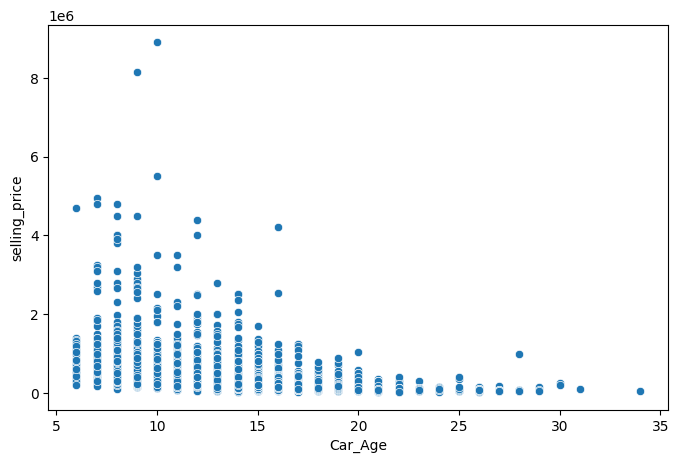

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Car_Age',
    y='selling_price',
    data=df
)

plt.show()

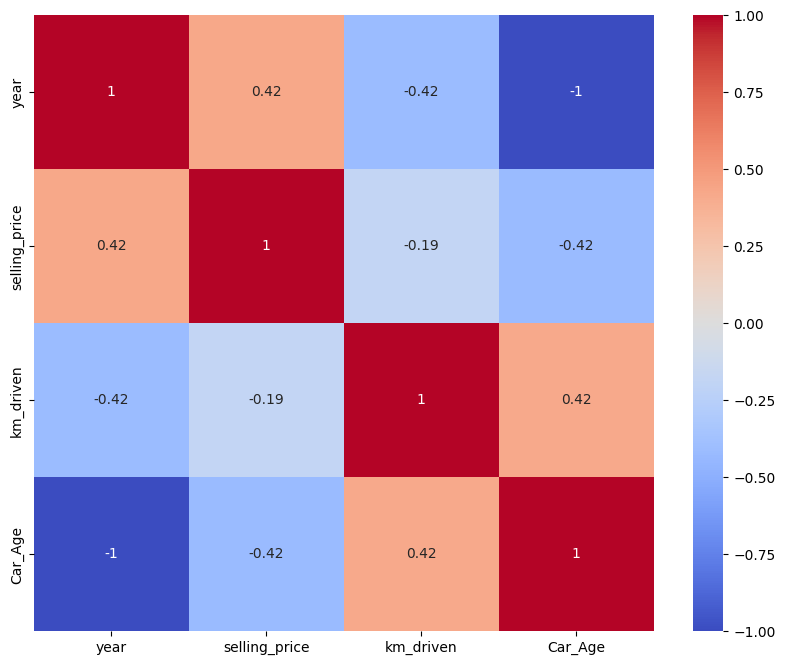

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [21]:
X = df.drop(
    ['selling_price','name'],
    axis=1
)

y = df['selling_price']

### One-Hot Encoding Categorical Features

To prepare the categorical features for the linear regression model, we need to convert them into a numerical format. One-hot encoding creates new binary columns for each category, where a '1' indicates the presence of that category and '0' indicates its absence.

In [22]:
# This cell is no longer needed as one-hot encoding is now handled before train_test_split in cell zw-Z0CSUwWIS.

In [23]:
X = pd.get_dummies(X, columns=['fuel', 'seller_type', 'transmission', 'owner', 'Brand'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2861, 42)
X_test shape: (716, 42)
y_train shape: (2861,)
y_test shape: (716,)


The `X` DataFrame has been updated with one-hot encoded columns. Now, we need to re-split the data into training and testing sets to ensure the split reflects these changes.

In [24]:
# This cell is no longer needed as train_test_split is now handled after one-hot encoding in cell zw-Z0CSUwWIS.

In [25]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

With the categorical features converted and the data re-split, we can now proceed to train the Linear Regression model.

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [27]:
pred_lr = lr.predict(X_test)

In [28]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [29]:
def evaluate(actual,pred):

    print("MAE :",mean_absolute_error(actual,pred))

    print("RMSE :",np.sqrt(mean_squared_error(actual,pred)))

    print("R2 :",r2_score(actual,pred))

In [30]:
print("Linear Regression")

evaluate(y_test,pred_lr)

print("Random Forest")

evaluate(y_test,pred_rf)


Linear Regression
MAE : 180194.98702221768
RMSE : 385606.0860986143
R2 : 0.5384145989232201
Random Forest
MAE : 159293.6736403034
RMSE : 365093.63355667563
R2 : 0.5862168278996627


Two regression models were trained and compared: Linear Regression and Random Forest Regressor. Based on the evaluation metrics (MAE, RMSE, and R² score), the Random Forest Regressor outperformed the Linear Regression model.

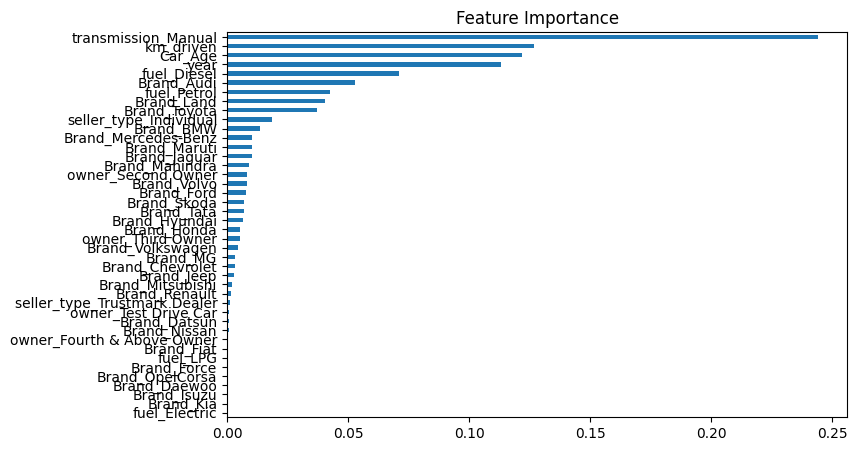

In [31]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()